# Player Style Clustering — K-Means on StatsBomb Event Data

**Objective:** Group players into tactical archetypes using unsupervised learning on per-90 StatsBomb metrics.

This notebook answers two questions:
1. **Who are the best progressive passers / pressers / chance creators per 90 minutes?** → Dashboard deliverable
2. **Which players have statistically similar playing styles?** → K-Means clustering deliverable

**Data:** `Statsbomb/events.parquet`, `Statsbomb/lineups.parquet`, `Statsbomb/matches.parquet`

**Pipeline:** Raw events → per-match player aggregations → per-90 normalization → PCA → K-Means → cluster profiles

---
## 0. Setup

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style='whitegrid', palette='tab10')

import pathlib
_cwd = pathlib.Path().resolve()
ROOT = str(_cwd.parent if _cwd.name == 'notebooks' else _cwd)
SB   = os.path.join(ROOT, 'data', 'Statsbomb')

SB_MATCHES  = os.path.join(SB, 'matches.parquet')
SB_EVENTS   = os.path.join(SB, 'events.parquet')
SB_LINEUPS  = os.path.join(SB, 'lineups.parquet')

FIGURES_DIR = os.path.join(ROOT, 'results', 'figures')
RESULTS_DIR = os.path.join(ROOT, 'results')
os.makedirs(FIGURES_DIR, exist_ok=True)

con = duckdb.connect()

def duck(sql: str) -> pd.DataFrame:
    return con.execute(sql).df()

print('Setup complete.')

Setup complete.


---
## 1. Data Overview

Quick check on available competitions and match counts to understand the dataset scope.

In [2]:
competitions = duck(f"""
    SELECT
        competition_name,
        COUNT(DISTINCT match_id) AS match_count,
        COUNT(DISTINCT season_name) AS season_count,
        MIN(match_date) AS earliest,
        MAX(match_date) AS latest
    FROM read_parquet('{SB_MATCHES}')
    WHERE gender = 'male'
      AND is_youth = false
    GROUP BY competition_name
    ORDER BY match_count DESC
""")

print(f"Total competitions: {len(competitions)}")
print(f"Total matches (men's senior): {competitions['match_count'].sum()}")
competitions

Total competitions: 16
Total matches (men's senior): 2923


,competition_name,match_count,season_count,earliest,latest
0,La Liga,868,18,1974-02-17,2021-05-16
1,Ligue 1,435,3,2015-08-07,2023-06-03
2,Premier League,418,2,2003-08-16,2016-05-17
3,Serie A,381,2,1986-11-09,2016-05-15
4,1. Bundesliga,340,2,2015-08-14,2024-05-18
5,FIFA World Cup,147,8,1958-06-24,2022-12-18
6,Indian Super league,115,1,2021-11-19,2022-03-20
7,UEFA Euro,102,2,2021-06-11,2024-07-14
8,African Cup of Nations,52,1,2024-01-13,2024-02-11
9,Copa America,32,1,2024-06-21,2024-07-15


---
## 2. Player Minutes from Lineups

We calculate each player's minutes played per match using `from_time` and `to_time` from the lineups table.
A player who plays the full match (from 0:00 to ~90:00+) gets ~90 minutes.
Substitutes get partial minutes.

**Note on nulls:** `position_name` is null for ~20% of rows. We keep these players since their event data
is still valid — the null only means no positional assignment was recorded (e.g. late substitutes).
Position is used for labeling only, not for clustering features.

In [3]:
lineups_raw = duck(f"""
    SELECT
        match_id,
        team_name,
        player_name,
        position_name,
        from_time,
        to_time
    FROM read_parquet('{SB_LINEUPS}')
    WHERE player_name IS NOT NULL
""")

print(f"Lineup rows: {len(lineups_raw):,}")
print(f"Null position_name: {lineups_raw['position_name'].isna().sum():,} ({lineups_raw['position_name'].isna().mean():.1%})")
print()
print("Sample from_time / to_time values:")
lineups_raw[['from_time','to_time']].dropna().head(10)

Lineup rows: 165,820
Null position_name: 34,179 (20.6%)

Sample from_time / to_time values:


,from_time,to_time
0,00:00,67:48
3,00:00,69:51
4,70:46,70:49
8,00:00,81:36
12,00:00,36:01
13,36:01,45:00
15,00:00,57:51
20,00:00,84:06
22,00:00,70:01
30,50:13,57:07


In [4]:
def parse_time_to_minutes(t):
    """
    Parse StatsBomb time strings to decimal minutes.
    Handles formats: '90:00', '45:30', '0:00', '1:30:00' (HH:MM:SS).
    Returns None if unparseable.
    """
    if pd.isna(t) or t == '':
        return None
    t = str(t).strip()
    parts = t.split(':')
    try:
        if len(parts) == 2:   # MM:SS
            return int(parts[0]) + int(parts[1]) / 60
        elif len(parts) == 3: # HH:MM:SS
            return int(parts[0]) * 60 + int(parts[1]) + int(parts[2]) / 60
    except (ValueError, TypeError):
        return None
    return None

lineups_raw['from_min'] = lineups_raw['from_time'].apply(parse_time_to_minutes).fillna(0)
lineups_raw['to_min']   = lineups_raw['to_time'].apply(parse_time_to_minutes)

# Where to_time is null (e.g. player played to end of match), use 90 as fallback
lineups_raw['to_min'] = lineups_raw['to_min'].fillna(90)

# Cap at 120 minutes (extra time)
lineups_raw['to_min'] = lineups_raw['to_min'].clip(upper=120)

lineups_raw['minutes_played'] = (lineups_raw['to_min'] - lineups_raw['from_min']).clip(lower=0)

print("Minutes played distribution:")
print(lineups_raw['minutes_played'].describe().round(1))

Minutes played distribution:
count   165820.000
mean        60.200
std         34.500
min          0.000
25%         23.500
50%         80.400
75%         90.000
max        120.000
Name: minutes_played, dtype: float64


In [5]:
# Aggregate to player-match level: sum minutes and take most common position
player_match_minutes = (
    lineups_raw
    .groupby(['match_id', 'player_name', 'team_name'])
    .agg(
        minutes_played=('minutes_played', 'sum'),
        position_name=('position_name', lambda x: x.dropna().mode().iloc[0] if not x.dropna().empty else None)
    )
    .reset_index()
)

# Season-level minutes: sum across all matches per player
player_season_minutes = (
    player_match_minutes
    .groupby(['player_name', 'team_name'])
    .agg(
        total_minutes=('minutes_played', 'sum'),
        matches_played=('match_id', 'count'),
        position_name=('position_name', lambda x: x.dropna().mode().iloc[0] if not x.dropna().empty else 'Unknown')
    )
    .reset_index()
)

print(f"Players in dataset: {len(player_season_minutes):,}")
print(f"Players with 450+ minutes: {(player_season_minutes['total_minutes'] >= 450).sum():,}")
print(f"Players with 900+ minutes: {(player_season_minutes['total_minutes'] >= 900).sum():,}")

Players in dataset: 14,094
Players with 450+ minutes: 5,198
Players with 900+ minutes: 3,332


---
## 3. Event Aggregation — Counting Actions per Player

We aggregate `events.parquet` (queried via DuckDB to avoid loading 755MB into RAM)
into per-player action counts.

### Feature Definitions

| Feature | Event Type | Condition | What it measures |
|---------|-----------|-----------|------------------|
| `shots` | Shot | any | Attacking threat |
| `xg` | Shot | SUM(shot_statsbomb_xg) | Expected goal quality |
| `passes` | Pass | any | Involvement/volume |
| `passes_completed` | Pass | pass_outcome IS NULL | Pass accuracy numerator |
| `passes_att_third` | Pass | location_x > 80 | Progressive/chance-creating passes |
| `pressures` | Pressure | any | Pressing intensity |
| `carries` | Carry | any | Ball-carrying / dribblers |
| `carries_att_third` | Carry | location_x > 80 | Attacking runs with ball |
| `duels` | Duel | any | Physical / aerial duels |
| `dribbles` | Dribble | any | 1v1 dribbling |
| `interceptions` | Interception | any | Defensive reading |
| `clearances` | Clearance | any | Defensive clearances |
| `ball_receipts` | Ball Receipt* | any | Receiving involvement |

**Note on progressive passes:** StatsBomb's full API includes pass end coordinates.
In this parquet export only `location_x/y` (event start) is available, so we proxy
progressive passing as passes originating in the attacking third (x > 80).

In [6]:
# This query runs DuckDB directly on the parquet file — no full RAM load
player_events = duck(f"""
    SELECT
        player,
        team,
        match_id,

        -- Shots & xG
        COUNT(*) FILTER (WHERE type = 'Shot')                           AS shots,
        SUM(shot_statsbomb_xg) FILTER (WHERE type = 'Shot')             AS xg,

        -- Passing
        COUNT(*) FILTER (WHERE type = 'Pass')                           AS passes,
        COUNT(*) FILTER (WHERE type = 'Pass'
                           AND pass_outcome IS NULL)                     AS passes_completed,
        COUNT(*) FILTER (WHERE type = 'Pass'
                           AND location_x > 80)                         AS passes_att_third,

        -- Pressing
        COUNT(*) FILTER (WHERE type = 'Pressure')                       AS pressures,

        -- Carrying
        COUNT(*) FILTER (WHERE type = 'Carry')                          AS carries,
        COUNT(*) FILTER (WHERE type = 'Carry'
                           AND location_x > 80)                         AS carries_att_third,

        -- Defensive / duels
        COUNT(*) FILTER (WHERE type = 'Duel')                           AS duels,
        COUNT(*) FILTER (WHERE type = 'Dribble')                        AS dribbles,
        COUNT(*) FILTER (WHERE type = 'Interception')                   AS interceptions,
        COUNT(*) FILTER (WHERE type = 'Clearance')                      AS clearances,

        -- Ball receipt (involvement)
        COUNT(*) FILTER (WHERE type = 'Ball Receipt*')                  AS ball_receipts

    FROM read_parquet('{SB_EVENTS}')
    WHERE player IS NOT NULL
    GROUP BY player, team, match_id
""")

print(f"Player-match rows: {len(player_events):,}")
print(f"Unique players: {player_events['player'].nunique():,}")
player_events.head(3)

Player-match rows: 97,581
Unique players: 9,038


,player,team,match_id,shots,xg,passes,passes_completed,passes_att_third,pressures,carries,carries_att_third,duels,dribbles,interceptions,clearances,ball_receipts
0,Abigail Harrison,Bristol City WFC,2275122,1,0.029,11,8,1,7,5,1,3,1,0,0,13
1,Fara Williams,Reading WFC,2275122,6,0.686,54,34,28,9,52,35,3,5,1,0,87
2,Frankie Brown,Bristol City WFC,2275122,0,NaN,18,12,1,11,12,1,4,0,2,6,9


---
## 4. Per-90 Normalization

Join event counts with minutes played, then normalise to per-90-minute rates.
Apply the minimum 450 minutes filter (≈5 full matches) to ensure meaningful averages.

In [7]:
# Sum events across all matches per player
player_totals = (
    player_events
    .groupby(['player', 'team'])
    .sum(numeric_only=True)
    .reset_index()
    .rename(columns={'player': 'player_name', 'team': 'team_name'})
)

# Join with minutes
df = player_totals.merge(player_season_minutes, on=['player_name', 'team_name'], how='inner')

# Apply 450-minute filter
MIN_MINUTES = 450
df = df[df['total_minutes'] >= MIN_MINUTES].copy()
print(f"Players after {MIN_MINUTES}+ minute filter: {len(df):,}")

# Per-90 normalization
RAW_COLS = ['shots', 'xg', 'passes', 'passes_completed', 'passes_att_third',
            'pressures', 'carries', 'carries_att_third',
            'duels', 'dribbles', 'interceptions', 'clearances', 'ball_receipts']

for col in RAW_COLS:
    df[f'{col}_p90'] = df[col] / df['total_minutes'] * 90

# Pass completion % (ratio, not per-90)
df['pass_completion_pct'] = np.where(
    df['passes'] > 0,
    df['passes_completed'] / df['passes'] * 100,
    np.nan
)

# xG per shot (shooting quality)
df['xg_per_shot'] = np.where(df['shots'] > 0, df['xg'] / df['shots'], 0)

print("\nPer-90 feature distributions:")
p90_cols = [c for c in df.columns if c.endswith('_p90')]
df[p90_cols].describe().round(2)

Players after 450+ minute filter: 4,852

Per-90 feature distributions:


,shots_p90,xg_p90,passes_p90,passes_completed_p90,passes_att_third_p90,pressures_p90,carries_p90,carries_att_third_p90,duels_p90,dribbles_p90,interceptions_p90,clearances_p90,ball_receipts_p90
count,4852.000,4852.000,4852.000,4852.000,4852.000,4852.000,4852.000,4852.000,4852.000,4852.000,4852.000,4852.000,4852.000
mean,0.810,0.090,29.570,22.760,6.790,10.160,23.020,5.710,2.350,1.090,0.720,1.400,28.120
std,0.920,0.130,17.910,15.350,6.450,7.130,14.670,5.850,1.660,1.230,0.630,1.640,17.860
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.140,0.010,16.330,11.450,1.010,4.690,11.830,0.600,1.030,0.170,0.180,0.200,13.370
50%,0.480,0.040,28.440,20.580,5.440,9.610,21.860,4.140,2.310,0.670,0.600,0.780,26.930
75%,1.200,0.110,40.940,31.410,10.740,15.020,32.360,9.260,3.380,1.600,1.110,2.010,40.810
max,7.000,1.060,173.270,155.920,39.260,73.670,146.410,36.130,12.080,10.470,7.460,9.410,152.750


---
## 5. Top Players by Key Metric (Dashboard Question)

**Question: Who are the best progressive passers / pressers / chance creators per 90 minutes?**

These tables directly feed the Looker Studio dashboard (Page 2: Player Performance & Clusters).

In [8]:
def top_players(df, metric_col, label, n=15):
    cols = ['player_name', 'team_name', 'position_name', 'total_minutes', 'matches_played', metric_col]
    return (
        df[cols]
        .sort_values(metric_col, ascending=False)
        .head(n)
        .reset_index(drop=True)
        .rename(columns={metric_col: label})
    )

print("=" * 60)
print("TOP 15 — PASSERS (Passes in Attacking Third per 90)")
print("=" * 60)
display(top_players(df, 'passes_att_third_p90', 'att_third_passes_p90'))

print("=" * 60)
print("TOP 15 — PRESSERS (Pressures per 90)")
print("=" * 60)
display(top_players(df, 'pressures_p90', 'pressures_p90'))

print("=" * 60)
print("TOP 15 — CHANCE CREATORS (xG per 90)")
print("=" * 60)
display(top_players(df, 'xg_p90', 'xg_p90'))

TOP 15 — PASSERS (Passes in Attacking Third per 90)


,player_name,team_name,position_name,total_minutes,matches_played,att_third_passes_p90
0,Jordi Alba Ramos,Spain,Left Back,1086.500,14,39.264
1,Mesut Özil,Arsenal,Center Attacking Midfield,3044.167,35,37.459
2,Florian Wirtz,Bayer Leverkusen,Left Attacking Midfield,2383.367,32,36.402
3,Philip Foden,England,Right Wing,661.900,10,35.761
4,Samir Nasri,Manchester City,Left Wing,543.433,12,35.276
5,N'Golo Kanté,France,Right Center Midfield,482.550,6,35.250
6,David Josué Jiménez Silva,Manchester City,Center Attacking Midfield,1794.200,24,34.812
7,Joshua Kimmich,Germany,Right Back,1354.217,15,34.426
8,Mathieu Valbuena,Lyon,Center Attacking Midfield,1816.033,26,34.394
9,Neymar da Silva Santos Junior,Barcelona,Left Wing,9642.600,116,34.142


TOP 15 — PRESSERS (Pressures per 90)


,player_name,team_name,position_name,total_minutes,matches_played,pressures_p90
0,N'Golo Kanté,France,Right Center Midfield,482.550,6,73.671
1,Jose Luis Martí Soler,Mallorca,Left Defensive Midfield,596.867,7,39.506
2,Marco Crimi,Carpi,Right Center Midfield,1057.267,20,39.498
3,Mehdi Lacen,Racing Santander,Right Center Midfield,541.850,6,39.199
4,Mauro Wilney Arambarri Rosa,Getafe,Left Defensive Midfield,582.333,7,38.174
5,Fernando Rubén Gago,Real Madrid,Center Defensive Midfield,450.000,5,37.800
6,Paulo Assunção da Silva,Atlético Madrid,Left Defensive Midfield,487.150,6,36.395
7,Éver Maximiliano David Banega,Valencia,Center Attacking Midfield,557.617,7,36.154
8,Vincent Koziello,OGC Nice,Right Center Midfield,2707.900,35,35.164
9,Xabier Alonso Olano,Real Madrid,Left Center Midfield,695.883,8,33.368


TOP 15 — CHANCE CREATORS (xG per 90)


,player_name,team_name,position_name,total_minutes,matches_played,xg_p90
0,Lautaro Javier Martínez,Argentina,Left Center Forward,493.850,13,1.056
1,Samantha May Kerr,Chelsea FCW,Center Forward,1820.517,26,1.043
2,Pierre-Emerick Aubameyang,Borussia Dortmund,Center Forward,2472.950,31,1.011
3,Henrik Larsson,Barcelona,Center Forward,545.083,13,1.001
4,Lynn Raenie Williams,North Carolina Courage,Right Center Forward,822.717,10,0.956
5,Édson Arantes do Nascimento,Brazil,Right Center Forward,810.000,9,0.947
6,Nikita Parris,Manchester City WFC,Center Forward,1781.900,21,0.934
7,Chloe Kelly,England Women's,Right Wing,561.667,19,0.932
8,Victor Okoh Boniface,Bayer Leverkusen,Center Forward,1547.300,23,0.929
9,Cristiano Ronaldo dos Santos Aveiro,Portugal,Center Forward,1435.700,18,0.880


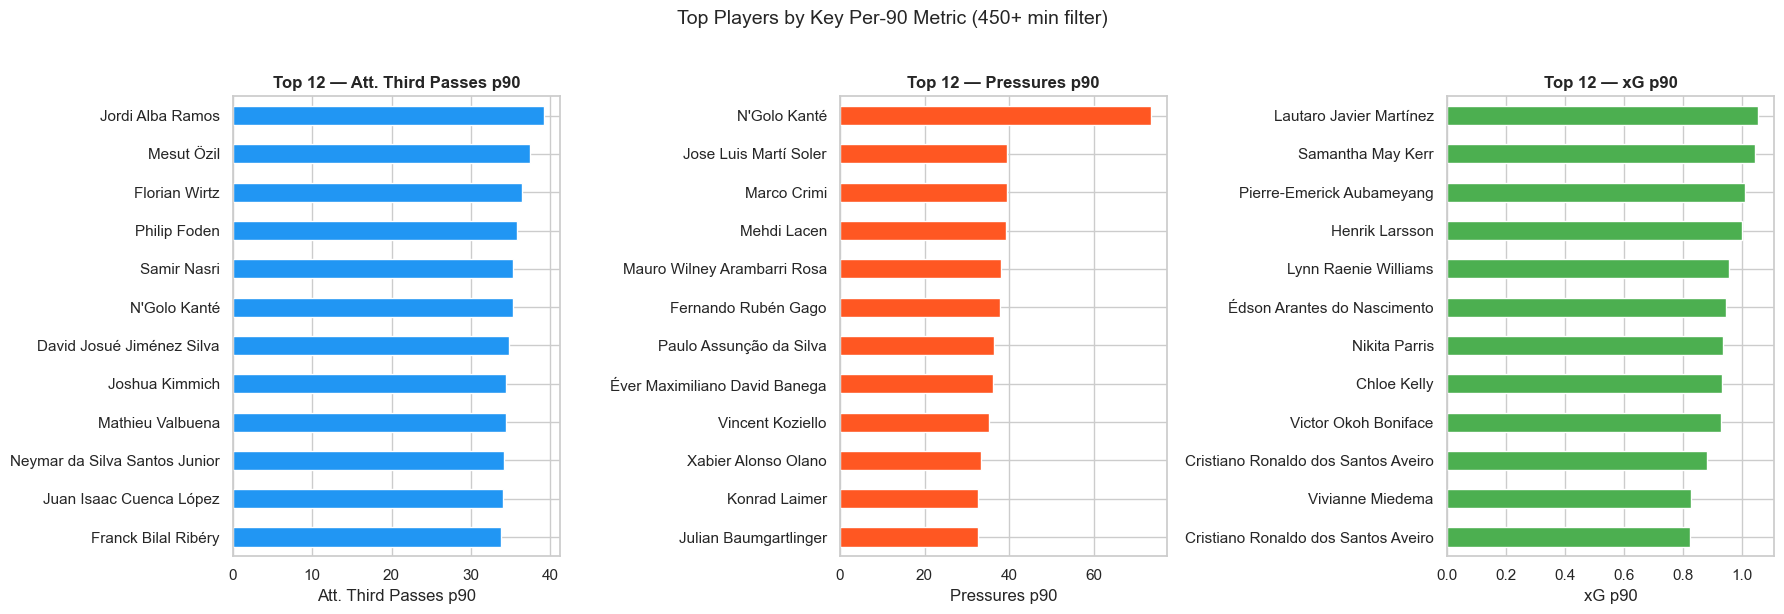

Saved: top_players_per90.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (metric, label, color) in zip(axes, [
    ('passes_att_third_p90', 'Att. Third Passes p90', '#2196F3'),
    ('pressures_p90',        'Pressures p90',         '#FF5722'),
    ('xg_p90',               'xG p90',                '#4CAF50'),
]):
    top = df.nlargest(12, metric)[['player_name', metric]].set_index('player_name')
    top[metric].sort_values().plot(kind='barh', ax=ax, color=color, edgecolor='white')
    ax.set_title(f'Top 12 — {label}', fontsize=12, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('')

plt.suptitle('Top Players by Key Per-90 Metric (450+ min filter)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'top_players_per90.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: top_players_per90.png")

---
## 6. Feature Selection for Clustering

We select features that capture distinct tactical dimensions.
Highly correlated features (e.g. `passes` and `ball_receipts`) are dropped
to avoid double-counting the same signal.

In [10]:
CLUSTER_FEATURES = [
    # Attacking
    'shots_p90',           # Shooting volume
    'xg_p90',              # Expected goals — goal threat quality
    'xg_per_shot',         # Shot quality (not volume-dependent)
    'dribbles_p90',        # 1v1 dribbling
    'carries_att_third_p90',  # Driving into dangerous areas

    # Chance creation / passing
    'passes_att_third_p90',   # Progressive / chance-creating passes
    'pass_completion_pct',    # Passing accuracy

    # Pressing / defensive work
    'pressures_p90',       # High press intensity
    'interceptions_p90',   # Defensive reading
    'clearances_p90',      # Last-ditch defending
    'duels_p90',           # Physical battles
]

print(f"Clustering on {len(CLUSTER_FEATURES)} features:")
for i, f in enumerate(CLUSTER_FEATURES, 1):
    print(f"  {i:2}. {f}")

Clustering on 11 features:
   1. shots_p90
   2. xg_p90
   3. xg_per_shot
   4. dribbles_p90
   5. carries_att_third_p90
   6. passes_att_third_p90
   7. pass_completion_pct
   8. pressures_p90
   9. interceptions_p90
  10. clearances_p90
  11. duels_p90


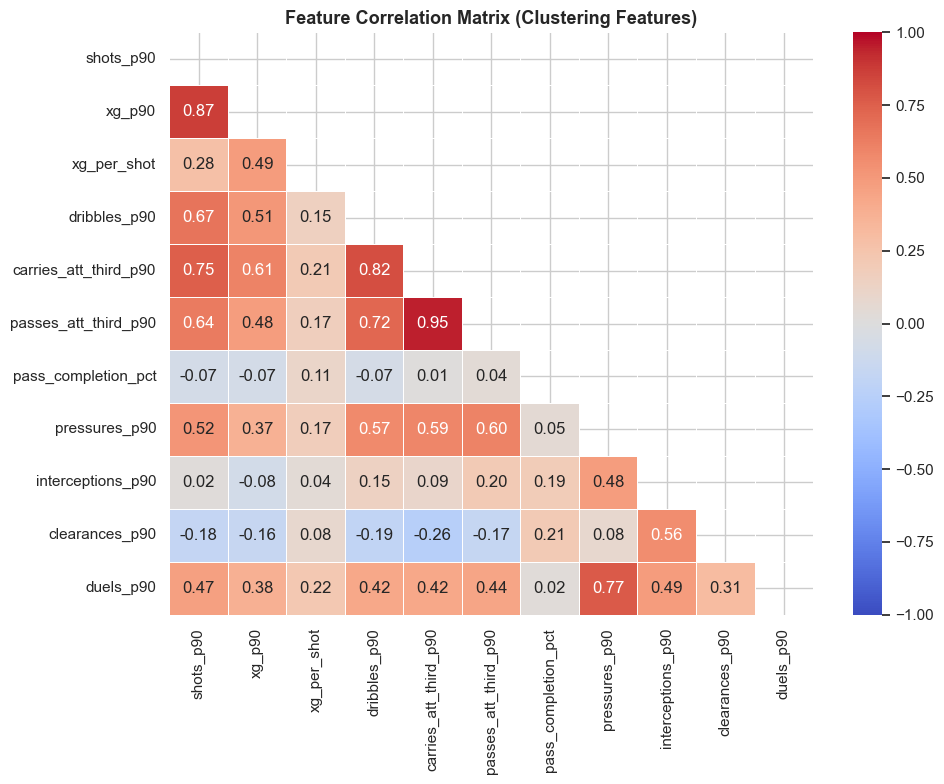

In [11]:
# Correlation heatmap to confirm feature independence
corr = df[CLUSTER_FEATURES].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5
)
ax.set_title('Feature Correlation Matrix (Clustering Features)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'feature_correlation.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Preprocessing — Imputation & Scaling

In [12]:
X_raw = df[CLUSTER_FEATURES].copy()

# Impute nulls with column median (rare, mainly xg_per_shot for players with 0 shots)
null_counts = X_raw.isna().sum()
if null_counts.any():
    print("Null counts before imputation:")
    print(null_counts[null_counts > 0])
    X_raw = X_raw.fillna(X_raw.median())

# Clip extreme outliers at 99th percentile to reduce distortion
for col in X_raw.columns:
    cap = X_raw[col].quantile(0.99)
    X_raw[col] = X_raw[col].clip(upper=cap)

# Standardize (zero mean, unit variance)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f"Feature matrix shape: {X_scaled.shape}")
print(f"Mean ≈ {X_scaled.mean():.4f} (should be ~0)")
print(f"Std  ≈ {X_scaled.std():.4f}  (should be ~1)")

Null counts before imputation:
pass_completion_pct    9
dtype: int64
Feature matrix shape: (4852, 11)
Mean ≈ -0.0000 (should be ~0)
Std  ≈ 1.0000  (should be ~1)


---
## 8. PCA — Dimensionality Reduction

PCA reduces the feature space before clustering, removes collinearity noise,
and enables 2D visualization.

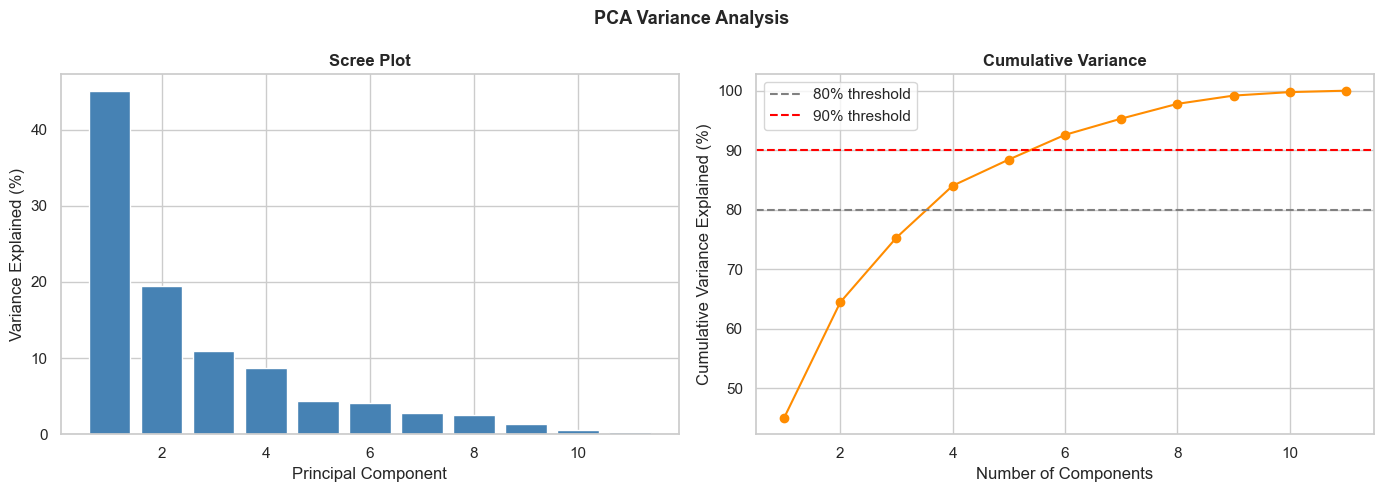

70% variance explained by 3 components
80% variance explained by 4 components
90% variance explained by 6 components


In [13]:
pca_full = PCA()
pca_full.fit(X_scaled)

explained = pca_full.explained_variance_ratio_.cumsum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
            pca_full.explained_variance_ratio_ * 100, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained (%)')
axes[0].set_title('Scree Plot', fontweight='bold')

# Cumulative variance
axes[1].plot(range(1, len(explained) + 1), explained * 100, 'o-', color='darkorange')
axes[1].axhline(80, linestyle='--', color='gray', label='80% threshold')
axes[1].axhline(90, linestyle='--', color='red', label='90% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Explained (%)')
axes[1].set_title('Cumulative Variance', fontweight='bold')
axes[1].legend()

plt.suptitle('PCA Variance Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'pca_variance.png'), dpi=150, bbox_inches='tight')
plt.show()

for threshold in [0.70, 0.80, 0.90]:
    n = (explained >= threshold).argmax() + 1
    print(f"{threshold:.0%} variance explained by {n} components")

In [14]:
# Use components that explain 80%+ variance for clustering
N_COMPONENTS = int((explained >= 0.80).argmax() + 1)
print(f"Using {N_COMPONENTS} PCA components (80%+ variance)")

pca = PCA(n_components=N_COMPONENTS, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Store 2D projection for visualization regardless of N_COMPONENTS
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_scaled)

df['pca_x'] = X_2d[:, 0]
df['pca_y'] = X_2d[:, 1]

# PCA loadings: which original features drive each component?
loadings = pd.DataFrame(
    pca.components_[:4].T,
    index=CLUSTER_FEATURES,
    columns=[f'PC{i+1}' for i in range(min(4, N_COMPONENTS))]
).round(3)

print("\nPCA Loadings (first 4 components):")
loadings.style.background_gradient(cmap='RdYlGn', axis=None)

Using 4 PCA components (80%+ variance)

PCA Loadings (first 4 components):


,PC1,PC2,PC3,PC4
shots_p90,0.389000,-0.162000,0.139000,-0.081000
xg_p90,0.343000,-0.193000,0.424000,-0.134000
xg_per_shot,0.196000,0.034000,0.721000,-0.046000
dribbles_p90,0.374000,-0.100000,-0.229000,0.061000
carries_att_third_p90,0.407000,-0.146000,-0.166000,0.201000
passes_att_third_p90,0.385000,-0.057000,-0.233000,0.228000
pass_completion_pct,0.002000,0.260000,0.229000,0.883000
pressures_p90,0.355000,0.240000,-0.182000,-0.083000
interceptions_p90,0.121000,0.570000,-0.164000,-0.040000
clearances_p90,-0.038000,0.574000,0.183000,-0.153000


---
## 9. K-Means: Choosing k — Elbow + Silhouette

We test k from 2 to 10 and use the elbow method (inertia) and silhouette score
to choose the optimal number of clusters.

k= 2  inertia=27,748  silhouette=0.3436
k= 3  inertia=19,737  silhouette=0.3356
k= 4  inertia=16,854  silhouette=0.3129
k= 5  inertia=14,980  silhouette=0.2751
k= 6  inertia=13,361  silhouette=0.2719
k= 7  inertia=12,024  silhouette=0.2783
k= 8  inertia=11,049  silhouette=0.2723
k= 9  inertia=10,130  silhouette=0.2768
k=10  inertia=9,539  silhouette=0.2701


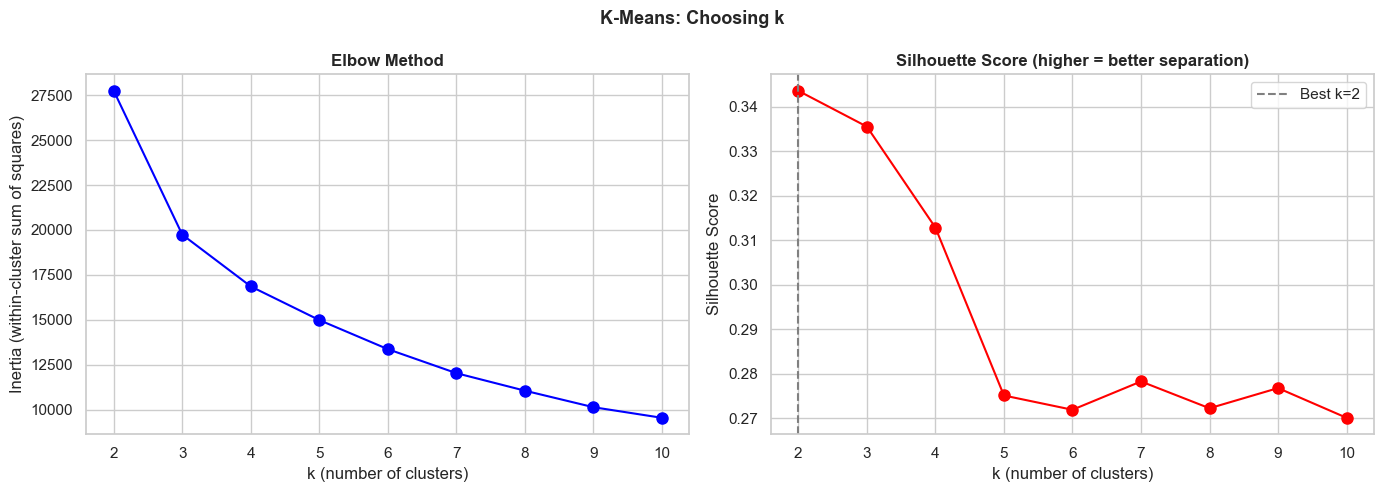


Highest silhouette score at k=2 (0.3436)


In [15]:
inertias = []
silhouettes = []
K_RANGE = range(2, 11)

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels))
    print(f"k={k:2d}  inertia={km.inertia_:,.0f}  silhouette={silhouettes[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_RANGE), inertias, 'bo-', markersize=8)
axes[0].set_xlabel('k (number of clusters)')
axes[0].set_ylabel('Inertia (within-cluster sum of squares)')
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].set_xticks(list(K_RANGE))

best_k_sil = list(K_RANGE)[silhouettes.index(max(silhouettes))]
axes[1].plot(list(K_RANGE), silhouettes, 'ro-', markersize=8)
axes[1].axvline(best_k_sil, linestyle='--', color='gray', label=f'Best k={best_k_sil}')
axes[1].set_xlabel('k (number of clusters)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score (higher = better separation)', fontweight='bold')
axes[1].set_xticks(list(K_RANGE))
axes[1].legend()

plt.suptitle('K-Means: Choosing k', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'kmeans_k_selection.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\nHighest silhouette score at k={best_k_sil} ({max(silhouettes):.4f})")

---
## 10. Final K-Means Model

Fit the final model with the chosen k. Assign cluster labels to each player.

In [16]:
# Why we override the silhouette recommendation:
# Silhouette picks k=2 because player feature distributions are continuous
# (no hard natural boundaries), so it always favours the coarsest split.
# For football analytics, k=2 is meaningless — it just separates high-volume
# from low-volume players.
#
# The elbow plot is more informative: the largest inertia drops occur at
# k=2->3->4, with diminishing returns from k=5 onward. Football analytics
# literature (StatsBomb, Wyscout, FBref) typically uses 5-8 archetypes:
# e.g. Pure Striker, Pressing Forward, Wide Carrier, Central Playmaker,
#      Defensive Midfielder, Defensive Defender
#
# We set K_FINAL = 6 as a reasonable starting point. Adjust after reviewing
# cluster profiles in cells 11-12.
K_FINAL = 6  # override silhouette — see note above

kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_pca)

print(f"Final model: k={K_FINAL}")
print(f"Silhouette score: {silhouette_score(X_pca, df['cluster']):.4f}")
print("\nCluster sizes:")
print(df['cluster'].value_counts().sort_index())

Final model: k=6
Silhouette score: 0.2719

Cluster sizes:
cluster
0     585
1    1280
2     561
3    1127
4     608
5     691
Name: count, dtype: int64


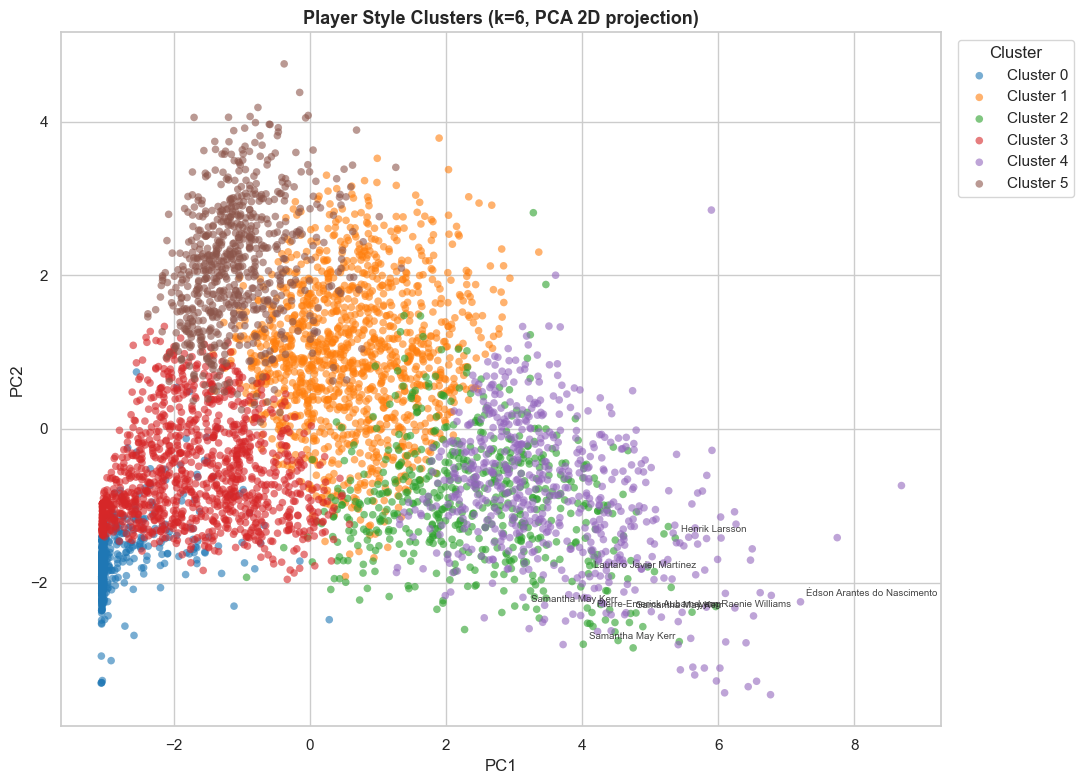

In [17]:
# PCA scatter: players coloured by cluster
fig, ax = plt.subplots(figsize=(11, 8))

palette = sns.color_palette('tab10', K_FINAL)
for k in range(K_FINAL):
    mask = df['cluster'] == k
    ax.scatter(
        df.loc[mask, 'pca_x'], df.loc[mask, 'pca_y'],
        c=[palette[k]], label=f'Cluster {k}',
        alpha=0.6, s=30, edgecolors='none'
    )

# Annotate a few notable top players
top_names = df.nlargest(6, 'xg_p90')['player_name'].tolist()
for _, row in df[df['player_name'].isin(top_names)].iterrows():
    ax.annotate(row['player_name'], (row['pca_x'], row['pca_y']),
                fontsize=7, alpha=0.85,
                xytext=(4, 4), textcoords='offset points')

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title(f'Player Style Clusters (k={K_FINAL}, PCA 2D projection)', fontsize=13, fontweight='bold')
ax.legend(title='Cluster', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'player_clusters_pca.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 11. Cluster Profiles

What does each cluster actually represent tactically?
We look at mean per-90 values per cluster to interpret the archetypes.

In [18]:
# Cluster mean profiles (original per-90 scale, not scaled)
profile_cols = ['shots_p90', 'xg_p90', 'passes_att_third_p90', 'pass_completion_pct',
                'pressures_p90', 'carries_att_third_p90', 'interceptions_p90',
                'clearances_p90', 'duels_p90', 'dribbles_p90']

cluster_profiles = df.groupby('cluster')[profile_cols].mean().round(3)

# Add cluster size and dominant position
cluster_profiles['n_players'] = df.groupby('cluster')['player_name'].count()
cluster_profiles['top_position'] = (
    df.groupby('cluster')['position_name']
    .agg(lambda x: x.dropna().mode().iloc[0] if not x.dropna().empty else 'Unknown')
)

print("Cluster Profiles (per-90 means):")
cluster_profiles

Cluster Profiles (per-90 means):


,shots_p90,xg_p90,passes_att_third_p90,pass_completion_pct,pressures_p90,carries_att_third_p90,interceptions_p90,clearances_p90,duels_p90,dribbles_p90,n_players,top_position
cluster,,,,,,,,,,,,
0,0.042,0.003,0.451,59.535,0.957,0.383,0.052,0.133,0.214,0.092,585,Goalkeeper
1,0.716,0.047,9.389,76.171,15.219,6.836,1.193,1.674,3.302,1.281,1280,Left Back
2,2.034,0.316,9.804,70.624,13.766,9.738,0.429,0.686,3.655,1.608,561,Center Forward
3,0.279,0.026,2.906,80.343,4.661,2.317,0.316,0.679,1.020,0.380,1127,Right Back
4,2.101,0.205,17.531,73.882,17.263,16.483,0.736,0.531,3.229,3.314,608,Left Wing
5,0.402,0.047,1.756,80.179,8.341,0.954,1.272,4.494,2.723,0.336,691,Left Center Back


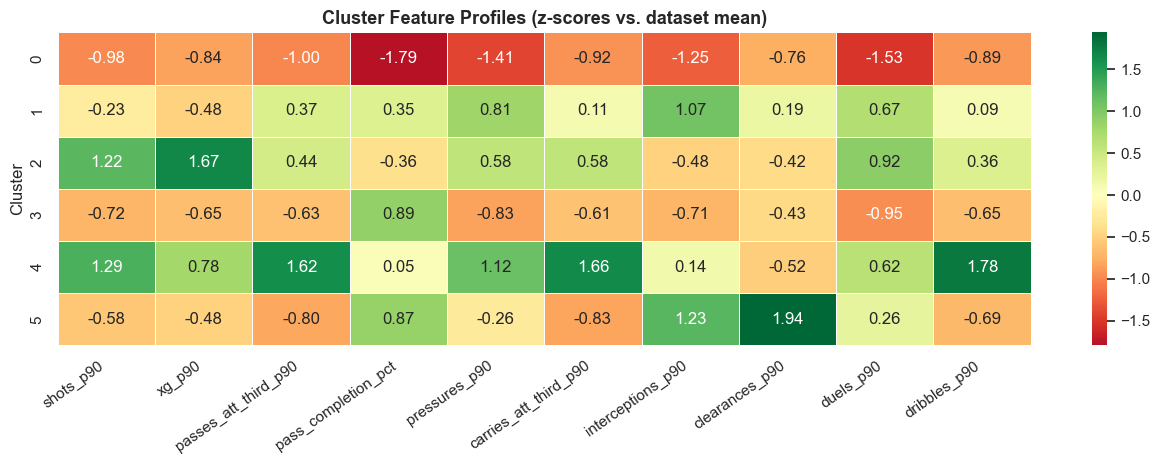

In [19]:
# Heatmap of z-scored cluster means — easier to see what each cluster specialises in
profile_z = cluster_profiles[profile_cols].apply(lambda x: (x - x.mean()) / x.std(), axis=0)

fig, ax = plt.subplots(figsize=(13, max(4, K_FINAL * 0.8)))
sns.heatmap(
    profile_z, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, linewidths=0.5, ax=ax
)
ax.set_title('Cluster Feature Profiles (z-scores vs. dataset mean)', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Cluster')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'cluster_profiles_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# ── Manual cluster label assignment ───────────────────────────────────────────
# Fill in after reviewing the profiles above. Examples:
# CLUSTER_LABELS = {
#     0: 'Deep-Lying Playmaker',
#     1: 'High Press Forward',
#     2: 'Defensive Midfielder',
#     3: 'Wide Carrier',
#     4: 'Box-to-Box',
#     5: 'Pure Striker',
# }

CLUSTER_LABELS = {k: f'Cluster {k}' for k in range(K_FINAL)}  # placeholder
df['cluster_label'] = df['cluster'].map(CLUSTER_LABELS)

print("Current cluster labels (update CLUSTER_LABELS above after reviewing profiles):")
print(df['cluster_label'].value_counts())

Current cluster labels (update CLUSTER_LABELS above after reviewing profiles):
cluster_label
Cluster 1    1280
Cluster 3    1127
Cluster 5     691
Cluster 4     608
Cluster 0     585
Cluster 2     561
Name: count, dtype: int64


---
## 12. Top Players per Cluster

For each cluster, show the top 5 players by total xG to identify the archetype representatives.
These names are useful for sanity-checking the cluster labels.

In [21]:
for k in range(K_FINAL):
    label = CLUSTER_LABELS[k]
    top = (
        df[df['cluster'] == k]
        [['player_name', 'team_name', 'position_name', 'total_minutes',
          'xg_p90', 'pressures_p90', 'passes_att_third_p90', 'cluster_label']]
        .sort_values('xg_p90', ascending=False)
        .head(8)
        .reset_index(drop=True)
    )
    print(f"\n{'='*60}")
    print(f"  Cluster {k}: {label}  (n={len(df[df['cluster']==k])})")
    print(f"{'='*60}")
    display(top)


  Cluster 0: Cluster 0  (n=585)


,player_name,team_name,position_name,total_minutes,xg_p90,pressures_p90,passes_att_third_p90,cluster_label
0,Miguel Ángel Borja Hernández,Colombia,Center Forward,553.283,0.137,0.651,0.488,Cluster 0
1,Kamil Grosicki,Poland,Left Wing,682.350,0.086,6.199,6.463,Cluster 0
2,Nicolás Federico López Alonso,Granada,Left Wing,518.100,0.067,5.385,5.559,Cluster 0
3,Felix Platte,Darmstadt 98,Center Forward,503.200,0.057,6.260,4.114,Cluster 0
4,Andros Townsend,Tottenham Hotspur,Right Wing,516.217,0.056,1.918,3.661,Cluster 0
5,Tim Matavž,Genoa,Center Forward,1275.900,0.055,7.900,2.892,Cluster 0
6,Sidney Sam,Schalke 04,Center Attacking Midfield,554.467,0.052,1.136,0.649,Cluster 0
7,Victor Chinedu Anichebe,West Bromwich Albion,Center Forward,2166.550,0.051,2.243,2.285,Cluster 0



  Cluster 1: Cluster 1  (n=1280)


,player_name,team_name,position_name,total_minutes,xg_p90,pressures_p90,passes_att_third_p90,cluster_label
0,Joni Ensio Kauko,ATK Mohun Bagan,Center Attacking Midfield,1444.450,0.241,19.876,9.471,Cluster 1
1,Yohan Cabaye,Crystal Palace,Right Defensive Midfield,2694.333,0.220,22.748,10.956,Cluster 1
2,Melanie Leupolz,Chelsea FCW,Center Defensive Midfield,1609.267,0.207,18.456,8.221,Cluster 1
3,Michail Antonio,West Ham United,Right Back,2687.517,0.188,11.419,9.310,Cluster 1
4,Allie Long,OL Reign,Right Center Midfield,540.000,0.186,15.667,3.500,Cluster 1
5,Elin Ingrid Johanna Rubensson,Sweden Women's,Left Defensive Midfield,1425.750,0.184,15.907,5.997,Cluster 1
6,Sergio Busquets i Burgos,Spain,Center Defensive Midfield,1106.500,0.181,14.397,13.421,Cluster 1
7,Marco Parolo,Lazio,Left Center Midfield,2566.217,0.179,25.462,9.504,Cluster 1



  Cluster 2: Cluster 2  (n=561)


...

,player_name,team_name,position_name,total_minutes,xg_p90,pressures_p90,passes_att_third_p90,cluster_label
0,Mauro Emanuel Icardi Rivero,Paris Saint-Germain,Center Forward,822.733,0.282,7.110,3.172,Cluster 3
1,Michy Batshuayi Tunga,Belgium,Center Forward,1089.800,0.259,4.542,1.899,Cluster 3
2,Gonçalo Matias Ramos,Portugal,Center Forward,626.567,0.255,4.453,1.724,Cluster 3
3,Eric Dier,England,Center Defensive Midfield,590.250,0.230,9.759,2.745,Cluster 3
4,Manolo Gabbiadini,Napoli,Center Forward,1540.117,0.219,6.077,3.740,Cluster 3
5,Josef Alexander Martínez Mencia,Torino,Left Center Forward,2180.200,0.205,5.779,1.899,Cluster 3
6,Alexandre Rodrigues da Silva,Chelsea,Center Forward,850.883,0.202,1.798,1.163,Cluster 3
7,Khouma El Hadji Babacar,Fiorentina,Center Forward,1971.267,0.191,6.301,3.424,Cluster 3



  Cluster 4: Cluster 4  (n=608)


,player_name,team_name,position_name,total_minutes,xg_p90,pressures_p90,passes_att_third_p90,cluster_label
0,Édson Arantes do Nascimento,Brazil,Right Center Forward,810.000,0.947,15.889,21.667,Cluster 4
1,Chloe Kelly,England Women's,Right Wing,561.667,0.932,31.086,29.964,Cluster 4
2,Vivianne Miedema,Arsenal WFC,Center Forward,4873.867,0.827,14.182,16.656,Cluster 4
3,Neymar da Silva Santos Junior,Brazil,Left Wing,698.333,0.813,12.372,32.735,Cluster 4
4,Kylian Mbappé Lottin,Paris Saint-Germain,Center Forward,4345.617,0.798,8.243,26.240,Cluster 4
5,Samuel Eto''o Fils,Barcelona,Center Forward,6573.367,0.695,12.459,16.745,Cluster 4
6,Lionel Andrés Messi Cuccittini,Barcelona,Right Wing,42429.600,0.690,9.844,31.226,Cluster 4
7,Lionel Andrés Messi Cuccittini,Argentina,Right Center Forward,1637.167,0.675,10.610,20.780,Cluster 4



  Cluster 5: Cluster 5  (n=691)


,player_name,team_name,position_name,total_minutes,xg_p90,pressures_p90,passes_att_third_p90,cluster_label
0,Andreas Granqvist,Sweden,Left Center Back,450.000,0.388,5.000,1.200,Cluster 5
1,Leonardo Bonucci,Italy,Right Center Back,585.000,0.388,4.923,0.308,Cluster 5
2,Sergei Ignashevich,Russia,Left Center Back,450.000,0.387,5.000,0.000,Cluster 5
3,Wendie Renard,France Women's,Left Center Back,1348.983,0.369,5.070,0.801,Cluster 5
4,Chancel Mbemba Mangulu,Congo DR,Right Center Back,638.617,0.325,7.046,1.973,Cluster 5
5,Moise Bombito,Canada,Right Center Back,540.000,0.283,7.333,1.333,Cluster 5
6,William Troost-Ekong,Nigeria,Center Back,899.267,0.267,5.404,0.901,Cluster 5
7,Mothobi Mvala,South Africa,Left Center Back,540.000,0.261,8.500,0.667,Cluster 5


---
## 13. Export — Cluster Assignments

Export the final cluster assignments for downstream use:
- Loaded into BigQuery by Dagster → feeds `mart_player_clusters`
- Powers Looker Studio Page 2 (Player Performance & Clusters)
- Enables chatbot queries like *"Find me players similar to Rodri"*

In [22]:
export_cols = [
    'player_name', 'team_name', 'position_name',
    'total_minutes', 'matches_played',
    'cluster', 'cluster_label',
    'pca_x', 'pca_y',
] + [c for c in df.columns if c.endswith('_p90')] + ['pass_completion_pct', 'xg_per_shot']

cluster_assignments = df[export_cols].sort_values(['cluster', 'player_name'])

out_path = os.path.join(RESULTS_DIR, 'cluster_assignments.parquet')
cluster_assignments.to_parquet(out_path, index=False)
print(f"Exported {len(cluster_assignments):,} players → {out_path}")
print(f"Columns: {cluster_assignments.columns.tolist()}")
cluster_assignments.head(5)

Exported 4,852 players → /Users/rabin/Documents/courses/UBC-MDS-Soccer-Capstone-2026/results/cluster_assignments.parquet
Columns: ['player_name', 'team_name', 'position_name', 'total_minutes', 'matches_played', 'cluster', 'cluster_label', 'pca_x', 'pca_y', 'shots_p90', 'xg_p90', 'passes_p90', 'passes_completed_p90', 'passes_att_third_p90', 'pressures_p90', 'carries_p90', 'carries_att_third_p90', 'duels_p90', 'dribbles_p90', 'interceptions_p90', 'clearances_p90', 'ball_receipts_p90', 'pass_completion_pct', 'xg_per_shot']


,player_name,team_name,position_name,total_minutes,matches_played,cluster,cluster_label,pca_x,pca_y,shots_p90,xg_p90,passes_p90,passes_completed_p90,passes_att_third_p90,pressures_p90,carries_p90,carries_att_third_p90,duels_p90,dribbles_p90,interceptions_p90,clearances_p90,ball_receipts_p90,pass_completion_pct,xg_per_shot
0,Aaren D''Silva,Hyderabad,Right Wing,610.400,15,0,Cluster 0,-2.186,-1.479,0.000,0.000,6.340,3.834,3.244,2.507,6.193,2.654,0.737,0.590,0.147,0.295,8.847,60.465,0.000
32,Abby Smith,Utah Royals,Goalkeeper,611.900,7,0,Cluster 0,-3.051,-1.660,0.000,0.000,26.622,16.620,0.000,0.147,17.944,0.000,0.000,0.000,0.000,0.294,13.532,62.431,0.000
59,Abdoulaye Diallo,Rennes,Goalkeeper,1260.000,14,0,Cluster 0,-3.026,-1.450,0.000,0.000,12.071,9.143,0.000,0.000,4.714,0.000,0.000,0.071,0.000,0.000,3.500,75.740,0.000
72,Abdul Rabeeh,Hyderabad,Center Attacking Midfield,595.100,9,0,Cluster 0,-2.088,-1.620,0.000,0.000,2.873,1.512,1.966,3.176,4.537,2.117,0.907,1.059,0.151,0.302,4.688,52.632,0.000
107,Accursio Bentivegna,Palermo,Left Midfield,1000.467,12,0,Cluster 0,-2.966,-1.681,0.000,0.000,0.540,0.360,0.360,0.180,0.810,0.360,0.000,0.090,0.000,0.000,0.720,66.667,0.000


---
## 14. Summary

| Item | Value |
|------|-------|
| Players (450+ min) | See cell 4 output |
| Clustering features | 11 per-90 metrics |
| PCA components used | See cell 8 output |
| K (final) | See cell 10 output |
| Silhouette score | See cell 10 output |
| Output | `cluster_assignments.parquet` |

### Next Steps for `src/ml/cluster.py`
1. Hardcode the chosen `K_FINAL` and `CLUSTER_LABELS` after reviewing profiles
2. Export the fitted `kmeans` model and `scaler` + `pca` as a `.joblib` artifact to GCS
3. Dagster loads this artifact and runs inference on new players each pipeline cycle

### What These Clusters Answer
- **Dashboard (Looker Studio Page 2):** Top passers / pressers / creators tables + PCA scatter with cluster badges
- **Chatbot:** *"Which players are most similar to [X]?"* → find players in same cluster, sort by feature similarity
- **Match prediction feature:** Cluster composition of a team's starting XI as a tactical fingerprint feature